## 1. Re-building our Training Dataset

In [1]:
import torch
import torch.nn.functional as F
import random

import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# read all the names into a list of words
words = open('../names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
m1 = min(len(name) for name in words)
m2 = max(len(name) for name in words)
m1, m2

(2, 15)

In [6]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
    
    print(w)
    context = [0] * block_size # start with padded context of just zero tokens
    #print(context)
    for char in w + '.':
        ix = stoi[char]
        X.append(context)
        Y.append(ix)
        #print(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop context and append
        #print(context)
        
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [9]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

## 2. Multilayer Perceptron (MLP)

In [11]:
C = torch.randn((27, 2))
C[5]

tensor([-0.4218,  0.7237])

In [12]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-0.4218,  0.7237])

In [14]:
C[X].shape

torch.Size([32, 3, 2])

In [23]:
X[13, 2], X[13, 1]

(tensor(1), tensor(0))

In [24]:
C[1], C[X][13, 2]

(tensor([ 0.8281, -1.6655]), tensor([ 0.8281, -1.6655]))

In [25]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [27]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [29]:
# emb @ W1 + b1

In [30]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # dependent on block size

torch.Size([32, 6])

In [31]:
torch.cat(torch.unbind(emb, 1), 1).shape # independent of block size

torch.Size([32, 6])

In [32]:
emb.view(emb.shape[0], 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [33]:
(emb.view(-1, 6) @ W1).shape, b1.shape

(torch.Size([32, 100]), torch.Size([100]))

In [34]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[-0.0445,  0.9992, -0.5555,  ..., -0.9769, -0.6275, -0.9915],
        [ 0.9131,  0.9910,  0.8613,  ...,  0.7715, -0.2234, -0.8478],
        [-0.4476, -0.3729, -0.8048,  ..., -0.8059,  0.2900, -0.9868],
        ...,
        [-0.0389,  1.0000,  0.7061,  ...,  0.2036, -0.9952, -0.4916],
        [-0.5227,  0.9999, -0.9902,  ..., -1.0000, -0.9995, -1.0000],
        [ 0.9901,  1.0000, -0.4175,  ..., -0.9686, -0.9932, -0.8628]])

In [35]:
h.shape

torch.Size([32, 100])

In [36]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [38]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [40]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob[1].sum()

tensor(1.)

In [41]:
torch.arange(32)  

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [42]:
prob[torch.arange(32), Y]   # 32 = shape of input X

tensor([8.3643e-09, 1.2254e-03, 9.0903e-06, 5.4048e-09, 1.9519e-02, 3.1598e-11,
        3.0364e-05, 2.4972e-04, 9.4093e-06, 1.1599e-14, 2.1977e-18, 9.7016e-01,
        2.2816e-15, 1.6653e-07, 2.2914e-11, 1.5283e-10, 2.8142e-12, 1.5644e-11,
        1.4491e-13, 7.7047e-09, 4.0952e-14, 3.2805e-04, 4.5462e-06, 5.5237e-05,
        7.2781e-01, 3.5000e-11, 6.7607e-11, 2.6982e-02, 1.3565e-10, 3.4812e-07,
        3.2159e-18, 2.2269e-01])

In [43]:
prob[torch.arange(32), Y].log().mean()

tensor(-17.9689)

In [45]:
# ------------------- MLP Implementation ---------------------------------
g = torch.Generator().manual_seed(2147483647)     # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [46]:
sum(p.nelement() for p in parameters)             # number of parameters in total

3481

In [47]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True) # (32, 27)
loss = -probs[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

In [49]:
F.cross_entropy(logits, Y)

tensor(17.7697)

## Training Loop + Overfitting One Batch

In [ ]:
g = torch.Generator().manual_seed(2147483647)     # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

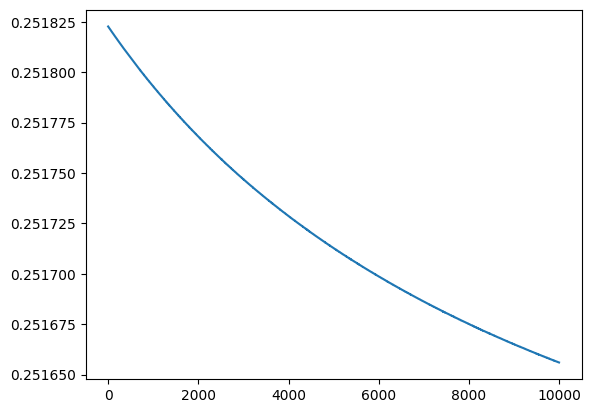

In [53]:
for p in parameters:
    p.requires_grad = True

losses = []
for k in range(10000):
    # forward pass
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32, 27)
    
    loss = F.cross_entropy(logits, Y)
    
    losses.append(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

plt.plot(range(len(losses)), losses)

In [ ]:
## Training on the Full Dataset + Minibatches

In [55]:
X, Y = [], []
for w in words:
    context = [0] * block_size # start with padded context of just zero tokens
    for char in w + '.':
        ix = stoi[char]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop context and append
X = torch.tensor(X)
Y = torch.tensor(Y)

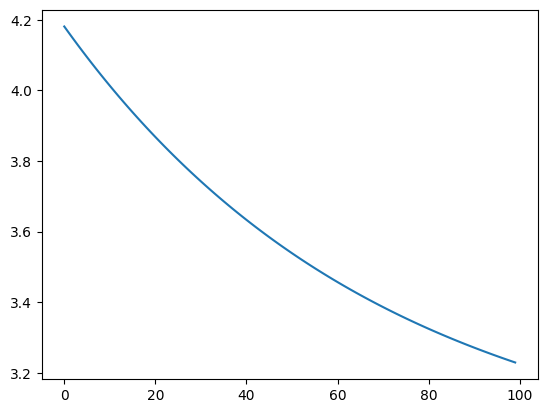

In [56]:
losses = []

for k in range(100):
    # forward pass
    emb = C[X] 
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32, 27)
    
    loss = F.cross_entropy(logits, Y)
    
    losses.append(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

plt.plot(range(len(losses)), losses)

In [62]:
ix = torch.randint(0, X.shape[0], (32, ))
print(ix)
ix.shape

tensor([124517, 147988,  62008, 191972, 159029,  92154, 120472,   1594,   5969,
        135427, 188716,   2422, 103588,  51513, 205619,  38525, 120644, 111096,
         73871, 209184, 159971, 127263, 141637,  49707, 201093,  48583, 129688,
         48704, 176013,   9250, 168830, 146894])


torch.Size([32])

In [68]:
for _ in range(10000):
    
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))
    
    # forward pass
    emb = C[X[ix]]                               
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)     
    logits = h @ W2 + b2                         
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update parameters
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())

2.6521520614624023


In [ ]:
## Learning Rate

In [69]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [71]:
lri = []
lrei = []
lossi = []
for i in range(1000):
    
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))
    
    # forward pass
    emb = C[X[ix]]                               # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
    logits = h @ W2 + b2                         # (32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    #print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update parameters
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    lri.append(lr)
    lrei.append(lre[i])
    lossi.append(loss.item())

print(loss.item())

8.345781326293945


Text(0, 0.5, 'Loss')

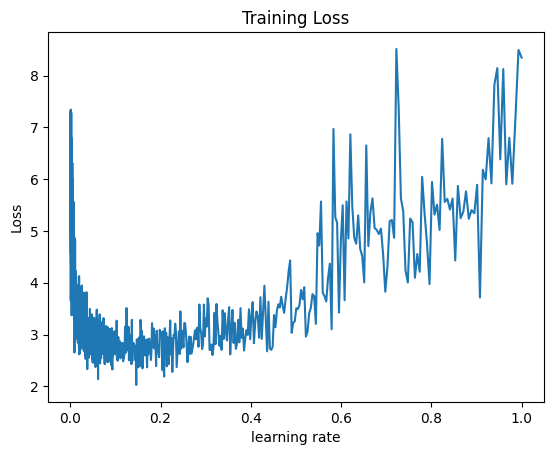

In [72]:
plt.plot(lri, lossi)  #
plt.title('Training Loss')
plt.xlabel('learning rate')
plt.ylabel('Loss')

Text(0, 0.5, 'Loss')

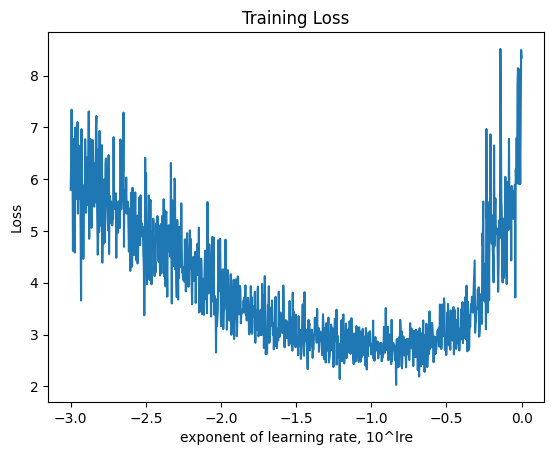

In [73]:
plt.plot(lrei, lossi) 
plt.title('Training Loss')
plt.xlabel('exponent of learning rate, 10^lre')
plt.ylabel('Loss')

## Train-Val-Test Splits 

In [79]:
def build_dataset(words):  
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [80]:
len(words)

32033

In [81]:
n1, n2-n1, len(words)-n2

(25626, 3203, 3204)

In [82]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [83]:
g = torch.Generator().manual_seed(2147483647)     # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [84]:
for p in parameters:
    p.requires_grad = True

In [85]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [86]:
lri = []
lossi = []

for i in range(10000):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    
    # forward pass
    emb = C[Xtr[ix]]                               # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
    logits = h @ W2 + b2                         # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update parameters
#     lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
#     lri.append(lr)
#     lossi.append(loss.item())

print(loss.item())

2.628981828689575


In [87]:
emb = C[Xtr]                                 # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
logits = h @ W2 + b2                         # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5735, grad_fn=<NllLossBackward0>)

In [88]:
emb = C[Xdev]                                # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
logits = h @ W2 + b2                         # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.5672, grad_fn=<NllLossBackward0>)

In [ ]:
## Experiment: Larger Hidden Layer

In [89]:
g = torch.Generator().manual_seed(2147483647)     # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [90]:
for p in parameters:
    p.requires_grad = True

In [91]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [92]:
lri = []
lossi = []
stepi = []

for i in range(30000):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    
    # forward pass
    emb = C[Xtr[ix]]                               # (32, 3, 2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
    logits = h @ W2 + b2                         # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update parameters
#     lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    #lri.append(lr)
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())

2.642242670059204


Text(0, 0.5, 'Loss')

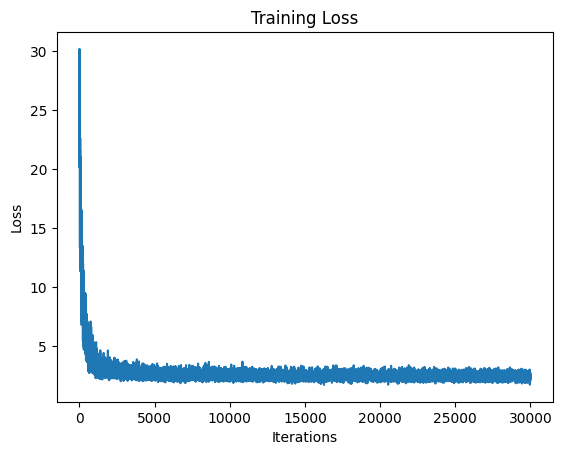

In [93]:
plt.plot(stepi, lossi)
plt.title('Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')

In [94]:
emb = C[Xtr]                                 # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
logits = h @ W2 + b2                         # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.4461, grad_fn=<NllLossBackward0>)

In [95]:
emb = C[Xdev]                                # (32, 3, 2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1)     # (32,100)
logits = h @ W2 + b2                         # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4386, grad_fn=<NllLossBackward0>)

## Visualize Character Embeddings

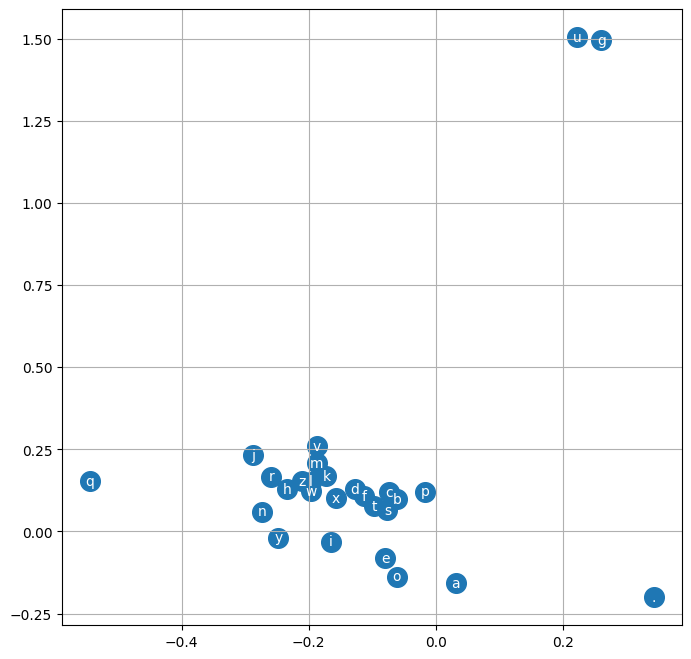

In [96]:
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data, C[:,1].data, s = 200)

for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(), itos[i], ha = "center", va = "center", color= "white")
plt.grid('minor')

## Experiment: Larger Embedding Size

In [111]:
g = torch.Generator().manual_seed(2147483647)     # for reproducibility
C = torch.randn((27, 30), generator=g)
W1 = torch.randn((90, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [112]:
for p in parameters:
    p.requires_grad = True

In [113]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [114]:
lri = []
lossi = []
stepi = []

In [116]:
for i in range(50000):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    
    # forward pass
    emb = C[Xtr[ix]]                               # (32, 3, 2)
    h = torch.tanh(emb.view(-1,90) @ W1 + b1)     # (32,100)
    logits = h @ W2 + b2                         # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update parameters
#     lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    #lri.append(lr)
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

3.0302228927612305


Text(0, 0.5, 'Log loss')

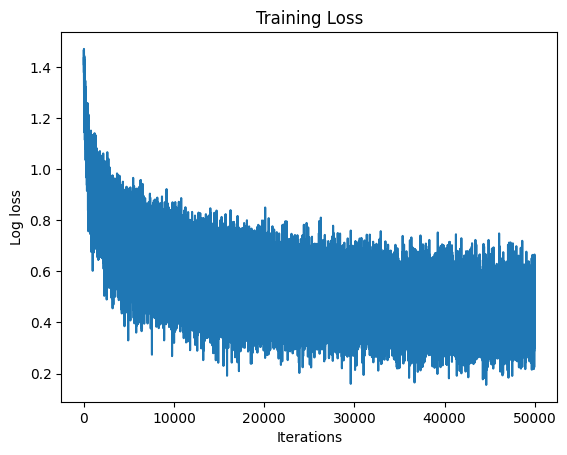

In [117]:
plt.plot(stepi, lossi)
plt.title('Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Log loss')

In [119]:
emb = C[Xtr]                                 # (32, 3, 2)
h = torch.tanh(emb.view(-1,90) @ W1 + b1)    # (32,100)
logits = h @ W2 + b2                         # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.7869, grad_fn=<NllLossBackward0>)

In [120]:
emb = C[Xdev]                                # (32, 3, 2)
h = torch.tanh(emb.view(-1,90) @ W1 + b1)    # (32,100)
logits = h @ W2 + b2                         # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.8844, grad_fn=<NllLossBackward0>)

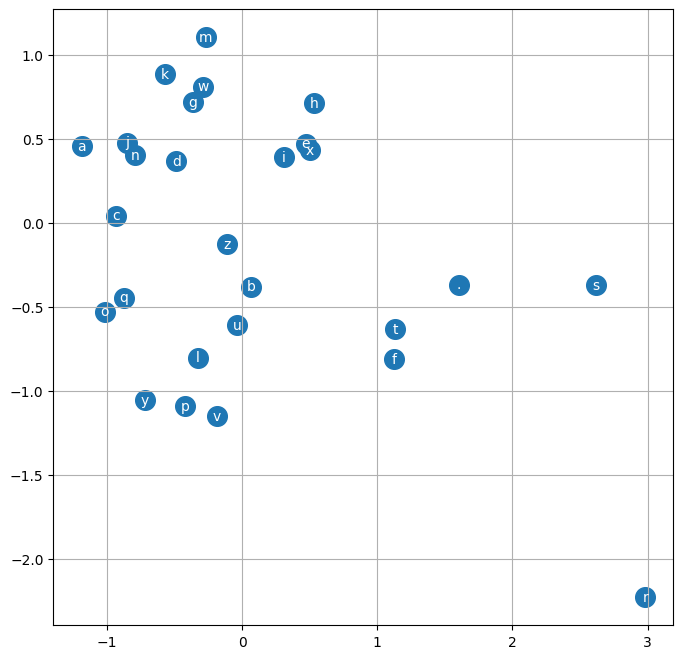

In [121]:
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data, C[:,1].data, s = 200)

for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(), itos[i], ha = "center", va = "center", color= "white")
plt.grid('minor')

## Sampling from the Model

In [124]:
context = [0] * block_size
C[torch.tensor([context])].shape, W1.shape

(torch.Size([1, 3, 30]), torch.Size([90, 200]))

In [125]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

eria.
kayanna.
elwem.
rham.
reh.
rucen.
ram.
raichedeeliah.
milohine.
eliearina.
seo.
zimalail.
nosadenrishiviafstnny.
weslelen.
puroy.
brey.
dariyah.
fael.
yuma.
maston.
